# Preprocessing Pipeline Demo

This notebook demonstrates the preprocessing pipeline for SERS spectra, following the methodology from Srivastava et al. 2024.

**Steps:**
1. Load amino acid spectra from batch1
2. Apply preprocessing pipeline (baseline correction, smoothing, normalization)
3. Select top 100 spectra by SNR for each amino acid
4. Plot mean fingerprints for all 19 amino acids

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from spectra import (
    read_batch_directory,
    PreprocessingPipeline,
    calculate_snr,
    select_top_by_snr,
)

# Set plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 1. Load Data

Load all amino acid spectra from the batch1 directory, excluding blank slides and test files.

In [12]:
# Load all amino acid data
raw_data = read_batch_directory(
    "data/batch1/",
    exclude_patterns=["BLANK", ".wdf", "test"]
)

print(f"Loaded {len(raw_data)} amino acid files")
print("\nAmino acids and spectra counts:")
for name, collection in sorted(raw_data.items()):
    print(f"  {name}: {len(collection)} spectra")

Loaded 19 amino acid files

Amino acids and spectra counts:
  Glycine\glycine_powder_532_.25s_100power_2394spectra: 2394 spectra
  L-Alanine\alanine_powder_532_.25s_100power_2565spectra: 2565 spectra
  L-Arginine\arginine_powder_532_0.25s_100power_2254spectra: 2254 spectra
  L-Asparagine\asparagine_powder_532_.25s_100power_2516spectra: 2516 spectra
  L-Aspartic acid\aspartic_acid_powder_532_.25s_100power_2478spectra: 2478 spectra
  L-Cysteine\cysteine_powder_532_.25s_100power_2491spectra: 2491 spectra
  L-Glutamic acid\glutamic_acid_powder_532_0.5s_50power_2100spectra: 2100 spectra
  L-Glutamine\glutamine_powder_532_.25s_100power_2420spectra: 2420 spectra
  L-Isoleucine\isoleucine_powder_532_.5s_100power_2166spectra: 2166 spectra
  L-Leucine\leucine_powder_532_.25s_100power_2585spectra: 2585 spectra
  L-Lysine\lysine_powder_532_.25s_100power_2478spectra: 2478 spectra
  L-Methionine\methionine_powder_532_.25s_100power_2442spectra: 2442 spectra
  L-Phenylalanine\phenylalanine_powder_532_

## 2. Apply Preprocessing Pipeline

Apply the full preprocessing pipeline from the paper:
1. **Baseline correction** - arPLS algorithm (λ=10⁵)
2. **Smoothing** - Savitzky-Golay filter (window=11, polyorder=3)
3. **Normalization** - Min-max scaling to [0, 1]

In [13]:
# Apply preprocessing to all amino acids
preprocessed_data = {}

print("Preprocessing amino acids...")
for name, collection in raw_data.items():
    # Extract amino acid name from path
    aa_name = name.split("\\")[0].split("/")[0]
    
    # Apply preprocessing pipeline
    processed = (
        PreprocessingPipeline(collection)
        .subtract_baseline(lam=1e5)
        .smooth(window_length=11, polyorder=3)
        .normalize()
        .result()
    )
    
    preprocessed_data[aa_name] = processed
    print(f"  {aa_name}: {len(collection)} -> {len(processed)} spectra")

print(f"\nTotal: {len(preprocessed_data)} amino acids preprocessed")

Preprocessing amino acids...
  Glycine: 2394 -> 2394 spectra
  L-Alanine: 2565 -> 2565 spectra
  L-Arginine: 2254 -> 2254 spectra
  L-Asparagine: 2516 -> 2516 spectra
  L-Aspartic acid: 2478 -> 2478 spectra
  L-Cysteine: 2491 -> 2491 spectra
  L-Glutamic acid: 2100 -> 2100 spectra
  L-Glutamine: 2420 -> 2420 spectra
  L-Isoleucine: 2166 -> 2166 spectra
  L-Leucine: 2585 -> 2585 spectra
  L-Lysine: 2478 -> 2478 spectra
  L-Methionine: 2442 -> 2442 spectra
  L-Phenylalanine: 2346 -> 2346 spectra
  L-Proline: 2196 -> 2196 spectra
  L-Serine: 2546 -> 2546 spectra
  L-Threonine: 2484 -> 2484 spectra
  L-Tryptophan: 2150 -> 2150 spectra
  L-Tyrosine: 2376 -> 2376 spectra
  L-Valine: 2535 -> 2535 spectra

Total: 19 amino acids preprocessed


## 3. Select Top 100 Spectra by SNR

For each amino acid, select the top 100 spectra with highest signal-to-noise ratio.

In [14]:
# Select top 100 spectra for each amino acid
N_SELECT = 100
selected_data = {}

print(f"Selecting top {N_SELECT} spectra by SNR...")
for aa_name, collection in preprocessed_data.items():
    n_select = min(N_SELECT, len(collection))
    selected = select_top_by_snr(collection, n=n_select)
    selected_data[aa_name] = selected
    
    # Calculate SNR stats for selected spectra
    snr_values = calculate_snr(selected)
    print(f"  {aa_name}: {n_select} spectra, SNR range: [{np.min(snr_values):.1f}, {np.max(snr_values):.1f}]")

print(f"\nTotal amino acids: {len(selected_data)}")

Selecting top 100 spectra by SNR...
  Glycine: 100 spectra, SNR range: [631.4, 1855.3]
  L-Alanine: 100 spectra, SNR range: [717.5, 1646.3]
  L-Arginine: 100 spectra, SNR range: [178.0, 331.5]
  L-Asparagine: 100 spectra, SNR range: [827.7, 1511.1]
  L-Aspartic acid: 100 spectra, SNR range: [373.6, 1161.3]
  L-Cysteine: 100 spectra, SNR range: [284.9, 677.9]
  L-Glutamic acid: 100 spectra, SNR range: [296.6, 686.1]
  L-Glutamine: 100 spectra, SNR range: [473.4, 1135.8]
  L-Isoleucine: 100 spectra, SNR range: [163.2, 452.4]
  L-Leucine: 100 spectra, SNR range: [233.9, 580.7]
  L-Lysine: 100 spectra, SNR range: [171.4, 243.9]
  L-Methionine: 100 spectra, SNR range: [248.7, 596.0]
  L-Phenylalanine: 100 spectra, SNR range: [278.2, 500.6]
  L-Proline: 100 spectra, SNR range: [229.4, 831.5]
  L-Serine: 100 spectra, SNR range: [2401.9, 3889.8]
  L-Threonine: 100 spectra, SNR range: [296.3, 713.4]
  L-Tryptophan: 100 spectra, SNR range: [178.7, 354.4]
  L-Tyrosine: 100 spectra, SNR range: [18

## 4. Calculate Mean Fingerprints

Calculate the mean spectrum for each amino acid from the selected top 100 spectra.

In [15]:
# Calculate mean fingerprints
mean_fingerprints = {}
wavelengths = None

for aa_name, collection in selected_data.items():
    # Get intensity matrix and calculate mean
    intensities = collection.to_intensity_matrix()
    mean_spectrum = np.mean(intensities, axis=0)
    std_spectrum = np.std(intensities, axis=0)
    
    mean_fingerprints[aa_name] = {
        'mean': mean_spectrum,
        'std': std_spectrum,
        'n_spectra': len(collection)
    }
    
    if wavelengths is None:
        wavelengths = collection.wavelengths

print(f"Calculated mean fingerprints for {len(mean_fingerprints)} amino acids")

Calculated mean fingerprints for 19 amino acids


## 5. Plot Mean Fingerprints

### 5.1 All Amino Acids in Grid

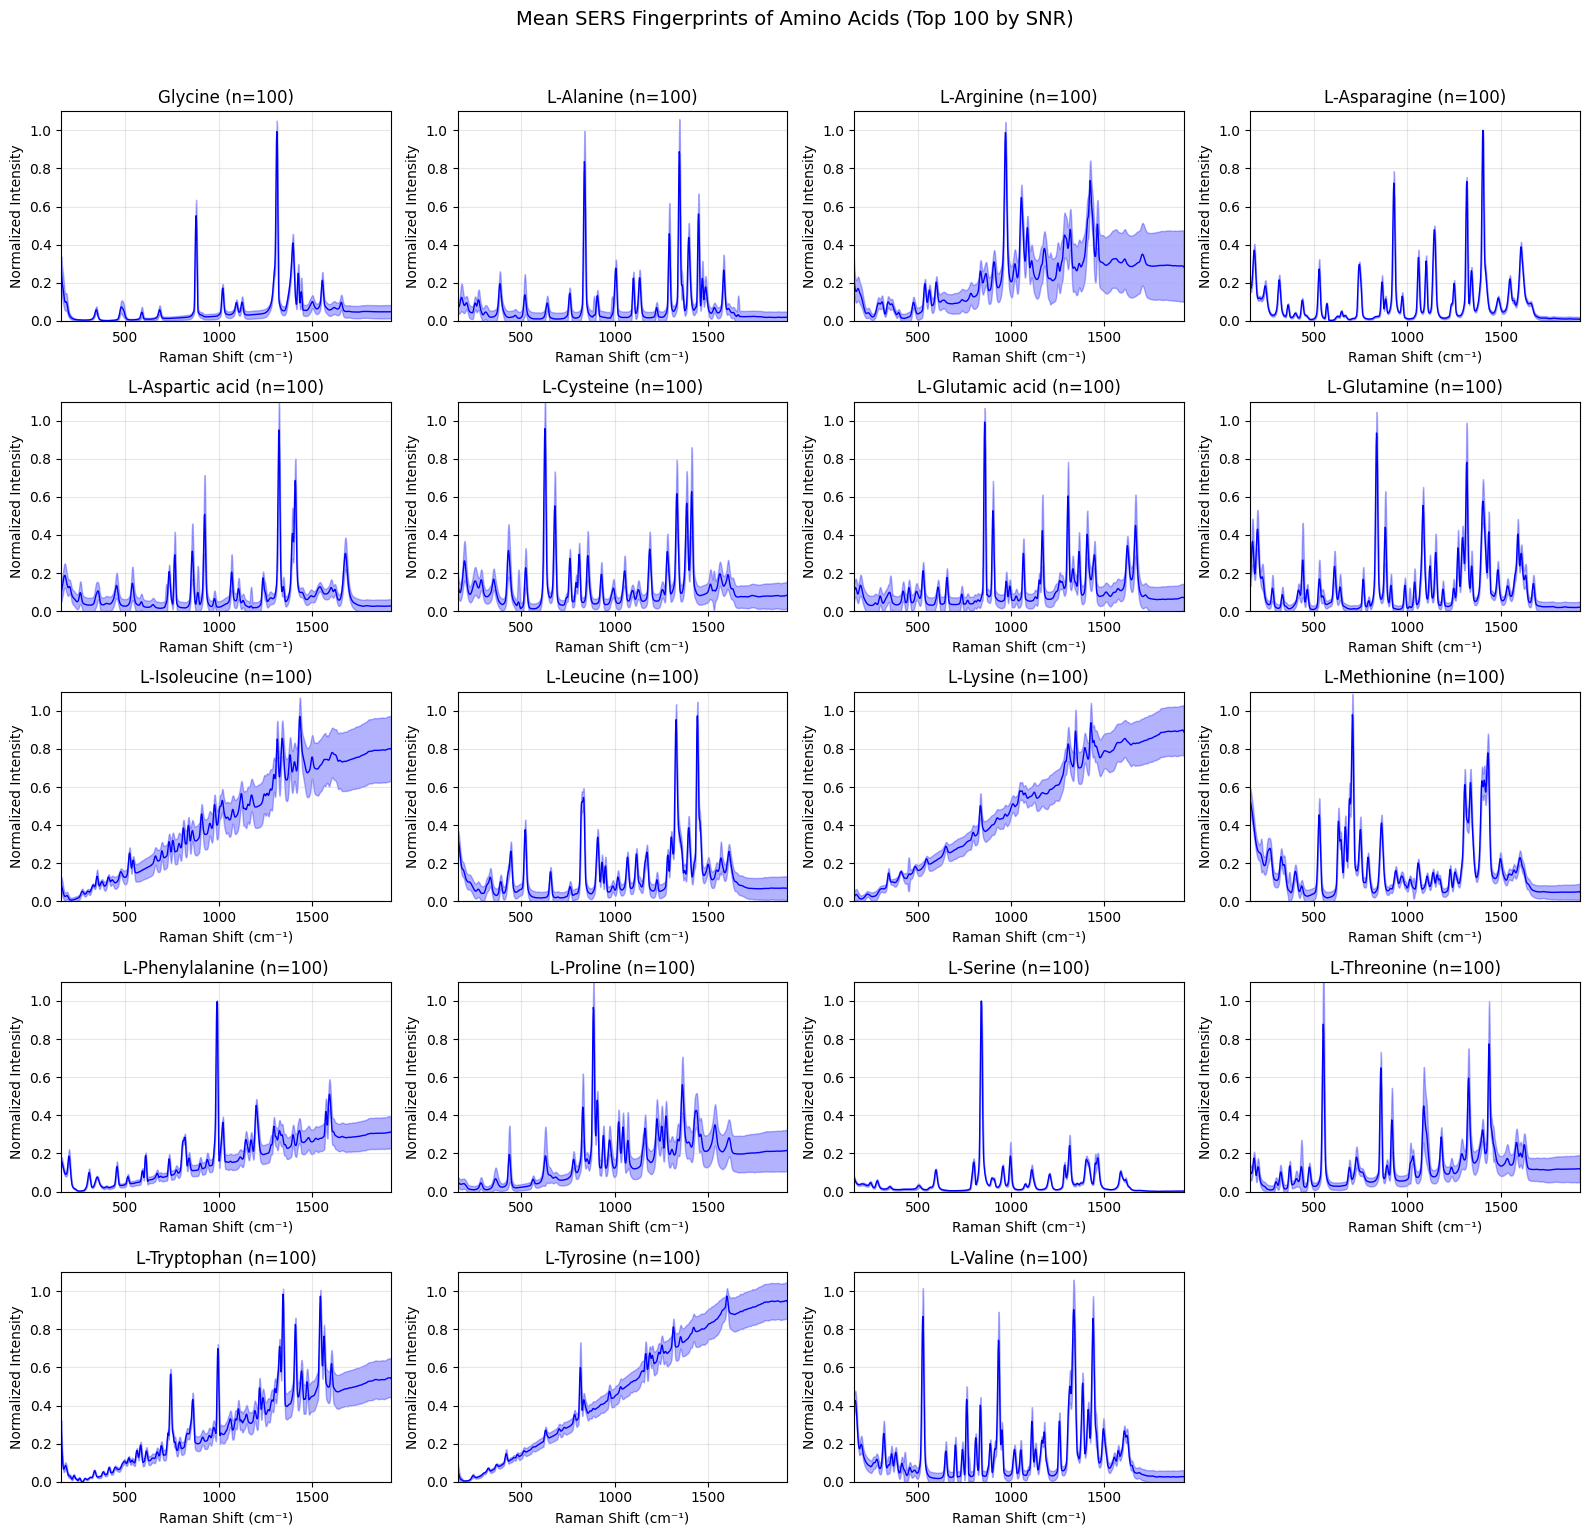

In [16]:
# Sort amino acids alphabetically
aa_names = sorted(mean_fingerprints.keys())
n_aa = len(aa_names)

# Create grid layout (5 rows x 4 columns for 19 amino acids)
n_cols = 4
n_rows = (n_aa + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for idx, aa_name in enumerate(aa_names):
    ax = axes[idx]
    data = mean_fingerprints[aa_name]
    
    # Plot mean with std shading
    ax.fill_between(
        wavelengths,
        data['mean'] - data['std'],
        data['mean'] + data['std'],
        alpha=0.3,
        color='blue'
    )
    ax.plot(wavelengths, data['mean'], 'b-', linewidth=1)
    
    ax.set_title(f"{aa_name} (n={data['n_spectra']})")
    ax.set_xlabel('Raman Shift (cm⁻¹)')
    ax.set_ylabel('Normalized Intensity')
    ax.set_xlim([wavelengths.min(), wavelengths.max()])
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(n_aa, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Mean SERS Fingerprints of Amino Acids (Top 100 by SNR)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 All Fingerprints Overlaid

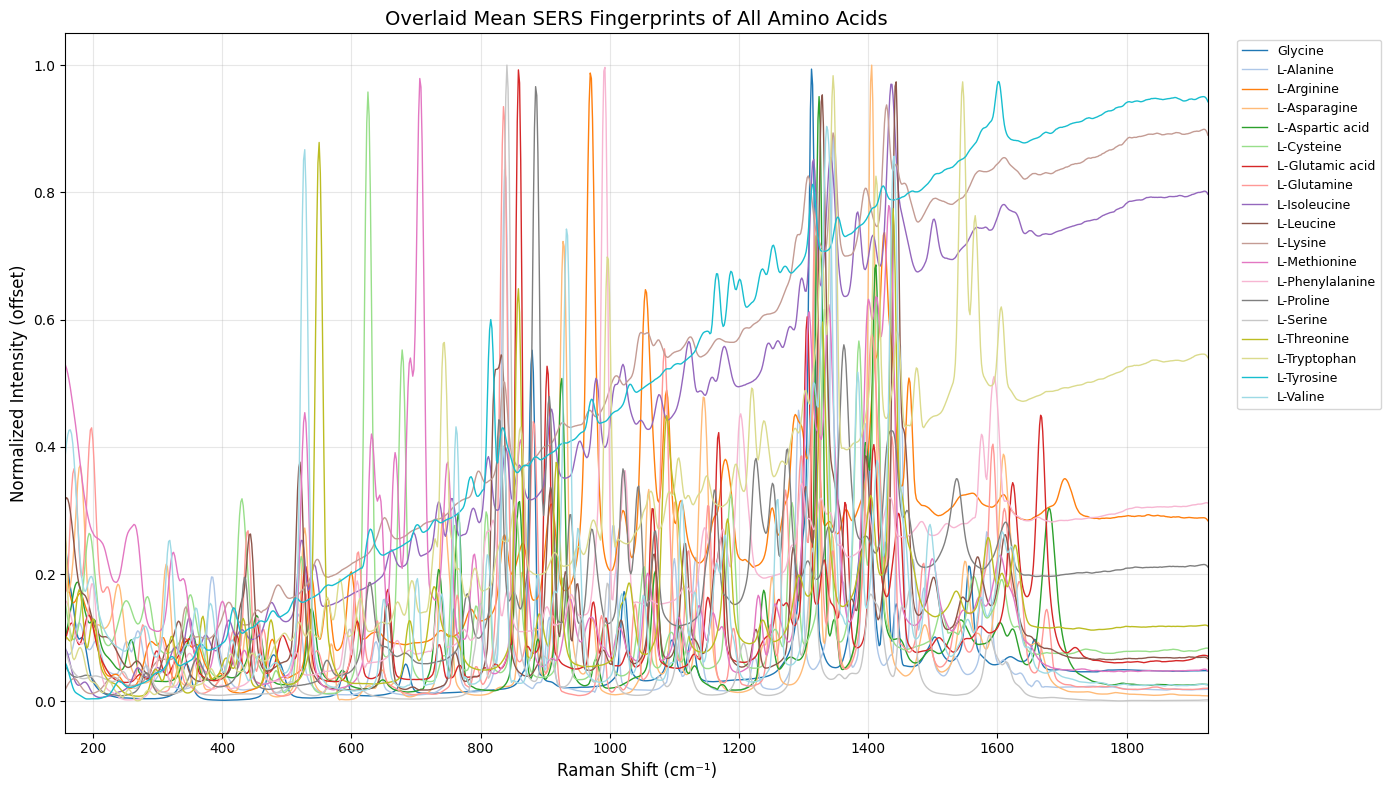

In [18]:
# Create colormap for amino acids
colors = plt.cm.tab20(np.linspace(0, 1, len(aa_names)))

fig, ax = plt.subplots(figsize=(14, 8))

for idx, aa_name in enumerate(aa_names):
    data = mean_fingerprints[aa_name]
    # Offset each spectrum slightly for visibility
    # offset = idx * 0.05
    ax.plot(
        wavelengths,
        data['mean'],
        color=colors[idx],
        linewidth=1,
        label=aa_name
    )

ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=12)
ax.set_ylabel('Normalized Intensity (offset)', fontsize=12)
ax.set_title('Overlaid Mean SERS Fingerprints of All Amino Acids', fontsize=14)
ax.set_xlim([wavelengths.min(), wavelengths.max()])
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 Stacked Fingerprints

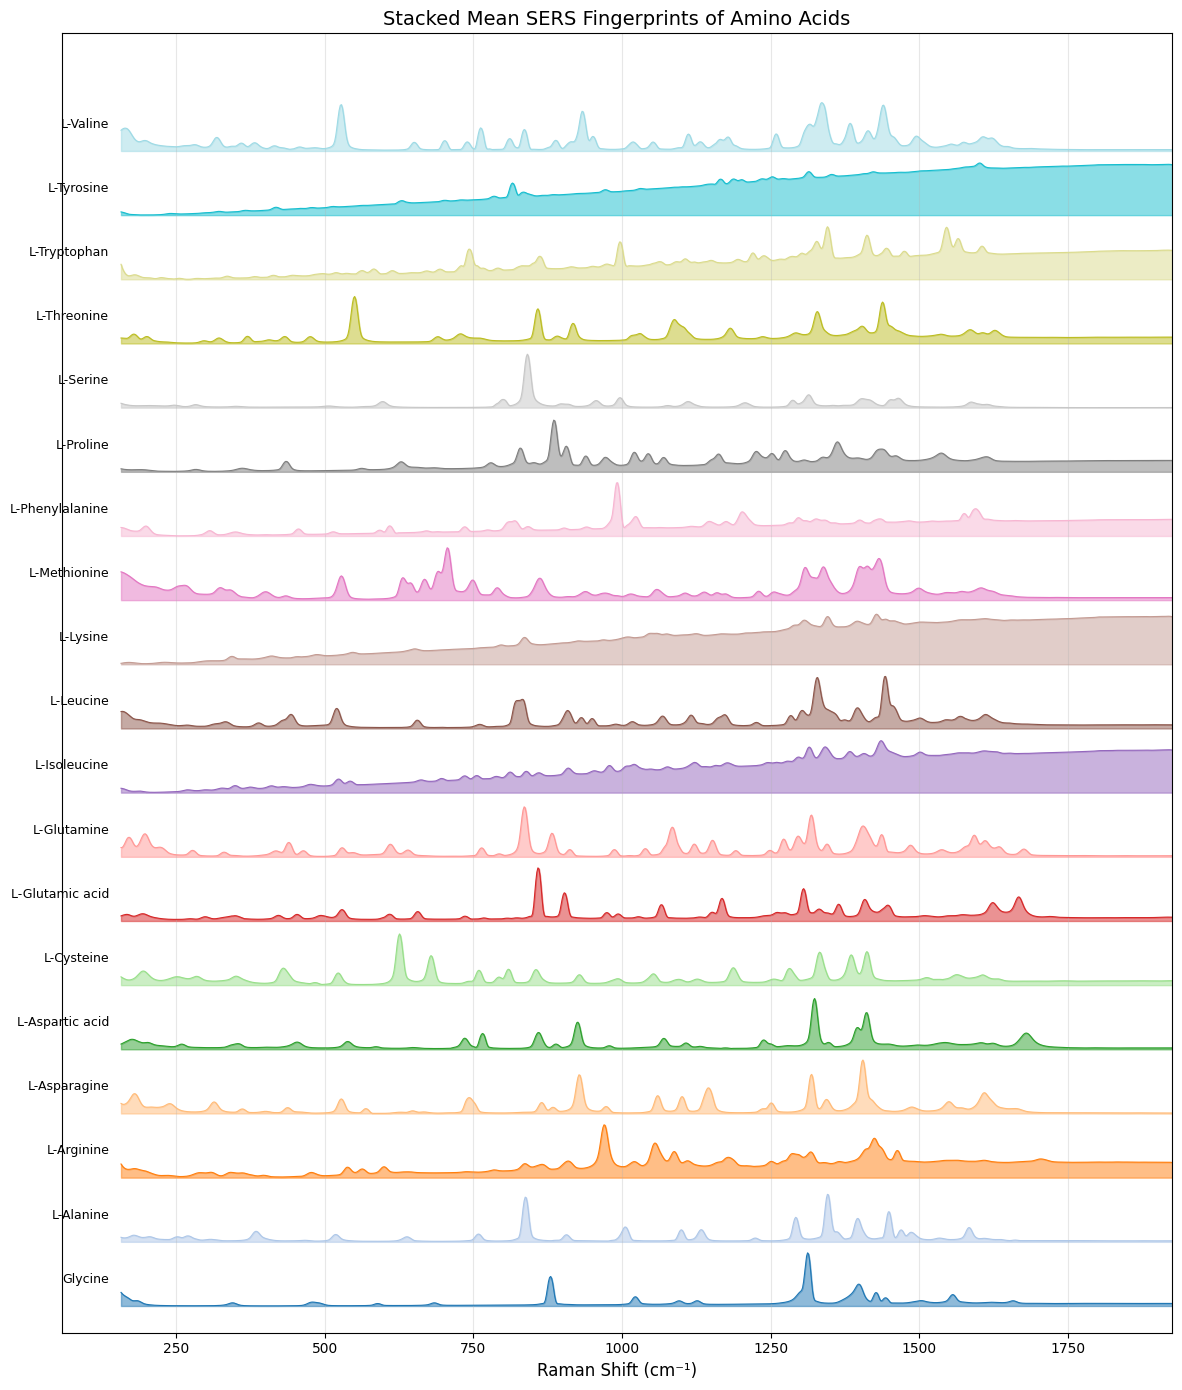

In [19]:
fig, ax = plt.subplots(figsize=(12, 14))

spacing = 1.2  # Vertical spacing between spectra

for idx, aa_name in enumerate(aa_names):
    data = mean_fingerprints[aa_name]
    offset = idx * spacing
    
    # Plot with fill
    ax.fill_between(
        wavelengths,
        offset,
        data['mean'] + offset,
        alpha=0.5,
        color=colors[idx]
    )
    ax.plot(wavelengths, data['mean'] + offset, color=colors[idx], linewidth=0.8)
    
    # Add label
    ax.text(
        wavelengths.min() - 20,
        offset + 0.5,
        aa_name,
        fontsize=9,
        ha='right',
        va='center'
    )

ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=12)
ax.set_title('Stacked Mean SERS Fingerprints of Amino Acids', fontsize=14)
ax.set_xlim([wavelengths.min() - 100, wavelengths.max()])
ax.set_ylim([-0.5, len(aa_names) * spacing + 1])
ax.set_yticks([])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 6. Summary Statistics

In [20]:
# Print summary table
print("Summary of Preprocessed Amino Acid Spectra")
print("=" * 70)
print(f"{'Amino Acid':<20} {'Raw':>10} {'Selected':>10} {'Mean SNR':>12} {'Max Peak':>12}")
print("-" * 70)

for aa_name in aa_names:
    raw_count = len(preprocessed_data[aa_name])
    selected_count = mean_fingerprints[aa_name]['n_spectra']
    snr_values = calculate_snr(selected_data[aa_name])
    mean_snr = np.mean(snr_values)
    max_peak = np.max(mean_fingerprints[aa_name]['mean'])
    
    print(f"{aa_name:<20} {raw_count:>10} {selected_count:>10} {mean_snr:>12.1f} {max_peak:>12.3f}")

print("=" * 70)
total_raw = sum(len(c) for c in preprocessed_data.values())
total_selected = sum(d['n_spectra'] for d in mean_fingerprints.values())
print(f"{'TOTAL':<20} {total_raw:>10} {total_selected:>10}")

Summary of Preprocessed Amino Acid Spectra
Amino Acid                  Raw   Selected     Mean SNR     Max Peak
----------------------------------------------------------------------
Glycine                    2394        100        884.5        0.994
L-Alanine                  2565        100        906.0        0.888
L-Arginine                 2254        100        215.3        0.988
L-Asparagine               2516        100        960.8        1.000
L-Aspartic acid            2478        100        505.2        0.951
L-Cysteine                 2491        100        362.6        0.958
L-Glutamic acid            2100        100        378.0        0.993
L-Glutamine                2420        100        539.8        0.935
L-Isoleucine               2166        100        190.9        0.970
L-Leucine                  2585        100        282.7        0.974
L-Lysine                   2478        100        190.8        0.937
L-Methionine               2442        100        301.9   

## 7. Export Mean Fingerprints

In [21]:
# Save mean fingerprints to numpy file
fingerprint_matrix = np.array([mean_fingerprints[aa]['mean'] for aa in aa_names])
std_matrix = np.array([mean_fingerprints[aa]['std'] for aa in aa_names])

np.savez(
    'amino_acid_fingerprints.npz',
    wavelengths=wavelengths,
    fingerprints=fingerprint_matrix,
    std=std_matrix,
    amino_acids=np.array(aa_names)
)

print("Saved mean fingerprints to 'amino_acid_fingerprints.npz'")
print(f"  - wavelengths: {wavelengths.shape}")
print(f"  - fingerprints: {fingerprint_matrix.shape}")
print(f"  - std: {std_matrix.shape}")
print(f"  - amino_acids: {len(aa_names)} names")

Saved mean fingerprints to 'amino_acid_fingerprints.npz'
  - wavelengths: (1023,)
  - fingerprints: (19, 1023)
  - std: (19, 1023)
  - amino_acids: 19 names
